In [ ]:
import bluequbit
from qiskit import QuantumCircuit

In [10]:
import matplotlib.pyplot as plt

In [11]:
bq = bluequbit.init("lEiTmm6zeLxxZ6q3aKBMsxwhrdnDr7vF")

[BQ-PYTHON-SDK][WARNING] - Beta version 0.18.1b1 of BlueQubit Python SDK is being used.


In [12]:
def plot_histogram(data):
    labels = list(data.keys())
    values = list(data.values())

    plt.bar(labels, values)
    plt.xlabel('States')
    plt.ylabel('Counts')
    plt.title('Quantum Circuit Measurement Results')
    plt.show()

# Quantum Volume Circuit

In [ ]:
from qiskit.circuit.library import quantum_volume

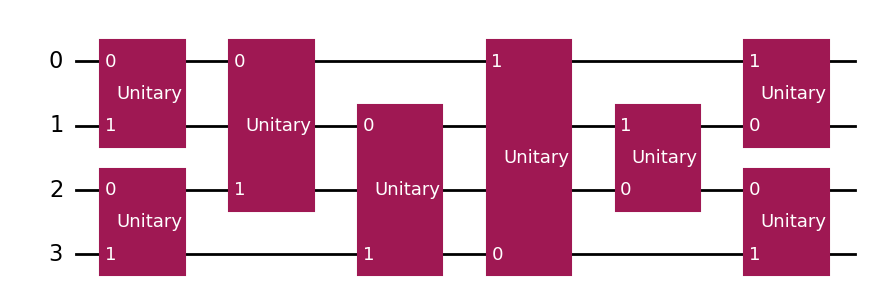

In [14]:
quantum_volume_circuit = quantum_volume(num_qubits=4, depth=4, seed=42)
quantum_volume_circuit.draw('mpl')

In [15]:
result = bq.run(quantum_volume_circuit, device='cpu', shots=100) 
print(result.get_counts())
# plot_histogram(result.get_counts())

[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: 6GDHUT1EAxE90m0j, device: cpu, run status: COMPLETED, created on: 2026-01-08 18:58:28 UTC, cost: $0.00, run time: 24 ms, queue time: 99 ms, num qubits: 4, shots: 100
{'0000': 18, '0001': 4, '0011': 1, '0100': 6, '0101': 10, '0110': 3, '0111': 1, '1000': 5, '1010': 9, '1011': 8, '1100': 23, '1101': 2, '1110': 6, '1111': 4}


# Random Circuit Sampling

In [16]:
import random
from itertools import cycle

In [17]:
def random_single_qubit_layer(qc, qubits):
    """Apply random single-qubit gates."""
    for q in qubits:
        gate_choice = random.choice(["I", "SX", "SY", "T"])
        if gate_choice == "SX":
            qc.sx(q)
        elif gate_choice == "SY":
            qc.sx(q)
            qc.rz(3.141592653589793 / 2, q)
            qc.sx(q)
        elif gate_choice == "T":
            qc.rz(3.141592653589793 / 4, q)
        # "I": do nothing

def cz_layer(qc, edges):
    """Apply CZ gates on a set of disjoint edges."""
    for q1, q2 in edges:
        qc.cz(q1, q2)

def greedy_matchings(edges, num_qubits):
    """
    Partition edges into disjoint matchings using a greedy algorithm.
    """
    remaining = list(edges)
    matchings = []

    while remaining:
        used = set()
        matching = []

        for e in remaining:
            q1, q2 = e
            if q1 not in used and q2 not in used:
                matching.append(e)
                used.add(q1)
                used.add(q2)

        matchings.append(matching)
        remaining = [e for e in remaining if e not in matching]

    return matchings


def random_circuit_sampling(
    num_qubits,
    edges,
    depth,
    seed=None,
):
    """
    Grid-agnostic Random Circuit Sampling circuit.

    Args:
        num_qubits: number of qubits
        edges: list of allowed 2Q interactions (tuples)
        depth: number of RCS layers
        seed: RNG seed (optional)
    """
    if seed is not None:
        random.seed(seed)

    qc = QuantumCircuit(num_qubits, num_qubits)
    qubits = list(range(num_qubits))

    # Precompute fixed entangling patterns
    matchings = greedy_matchings(edges, num_qubits)
    matching_cycle = cycle(matchings)

    for _ in range(depth):
        # 1Q random layer
        random_single_qubit_layer(qc, qubits)

        qc.barrier()

        # 2Q entangling layer (fixed pattern)
        cz_layer(qc, next(matching_cycle))

        qc.barrier()

    qc.measure(qubits, qubits)
    return qc

In [18]:
# 1D chain
edges = [(0,1), (1,2), (2,3), (3,4)]
random_circuit = random_circuit_sampling(5, edges, depth=10, seed=42)

# Heavy-hex–like graph
edges = [(0,1), (1,2), (2,3), (1,4), (4,5)]
random_circuit = random_circuit_sampling(6, edges, depth=12)

# Fully connected (theoretical)
edges = [(i, j) for i in range(5) for j in range(i+1, 5)]
random_circuit = random_circuit_sampling(5, edges, depth=8)

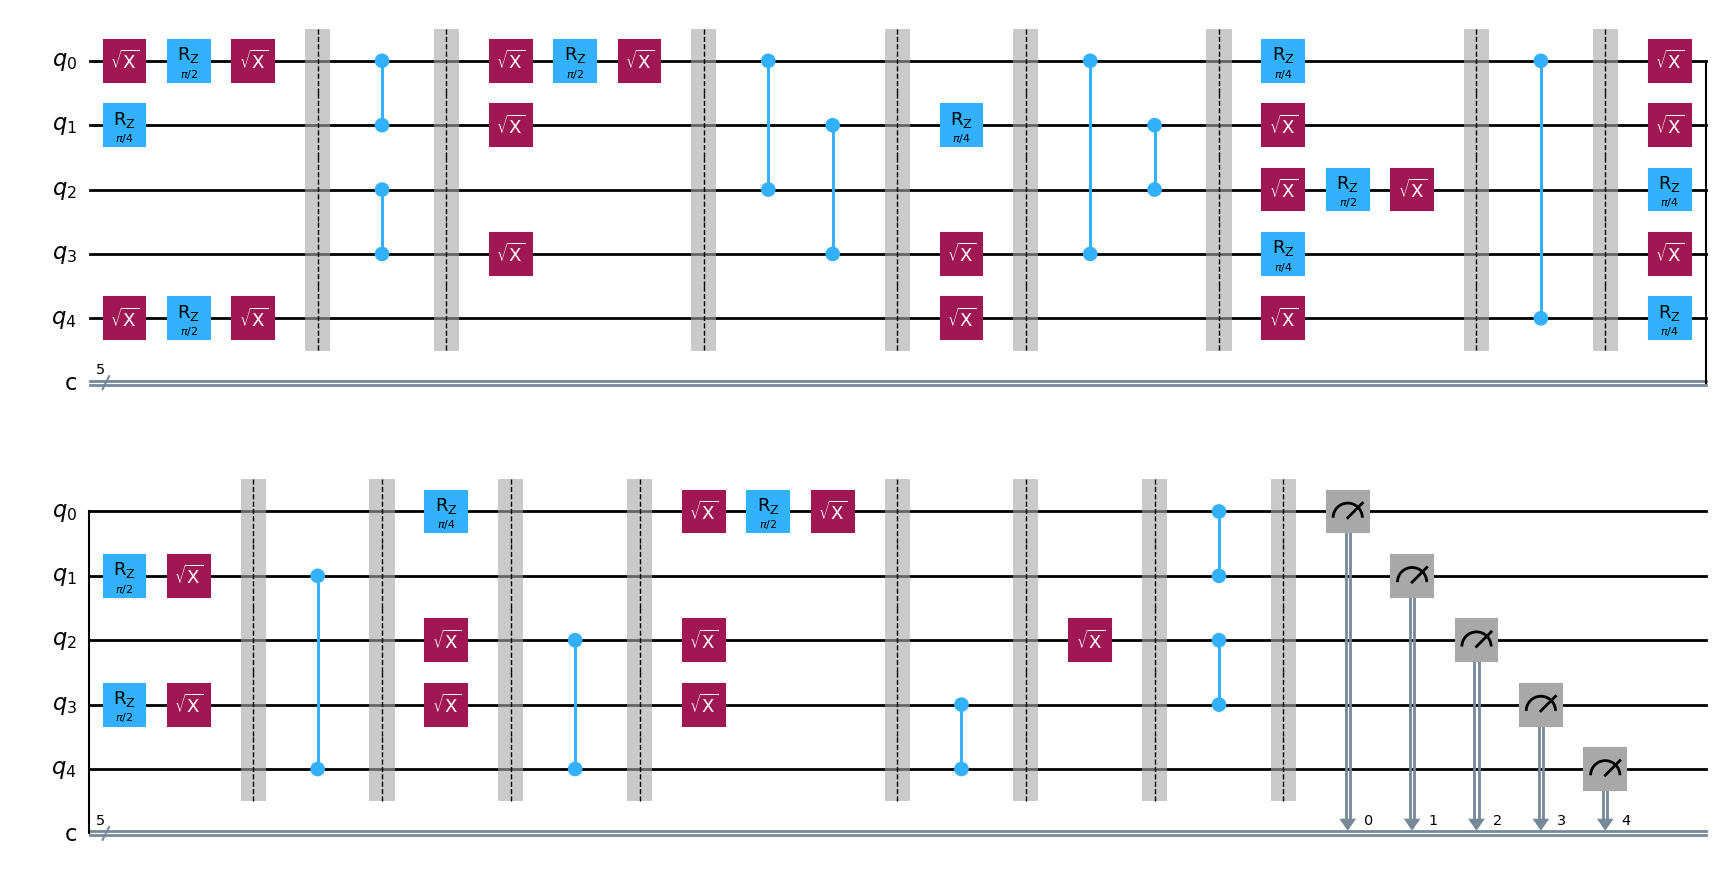

In [19]:
random_circuit.draw('mpl')

In [20]:
result = bq.run(random_circuit, device='cpu', shots=100) 
print(result.get_counts())
# plot_histogram(result.get_counts())

[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: ZslttBcIbZ0rMJwV, device: cpu, run status: COMPLETED, created on: 2026-01-08 18:58:29 UTC, cost: $0.00, run time: 12 ms, queue time: 101 ms, num qubits: 5, shots: 100
{'00010': 8, '00011': 1, '00110': 15, '00111': 1, '01000': 3, '01001': 2, '01100': 20, '01101': 4, '10010': 4, '10011': 1, '10110': 17, '10111': 6, '11000': 5, '11100': 10, '11101': 3}


# QFT

In [21]:
from qiskit.circuit.library import QFT

C:\Users\arulr\AppData\Local\Temp\ipykernel_19772\3896292778.py:1: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_circuit = QFT(num_qubits=4)


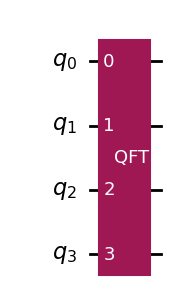

In [22]:
qft_circuit = QFT(num_qubits=4)
qft_circuit.draw('mpl')

In [23]:
result = bq.run(qft_circuit, device='cpu', shots=100) 
print(result.get_counts())
# plot_histogram(result.get_counts())

[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: R2Ru7dnSnwnDFuTh, device: cpu, run status: COMPLETED, created on: 2026-01-08 18:58:31 UTC, cost: $0.00, run time: 7 ms, queue time: 103 ms, num qubits: 4, shots: 100
{'0000': 6, '0001': 7, '0010': 9, '0011': 5, '0100': 5, '0101': 3, '0110': 2, '0111': 9, '1000': 5, '1001': 8, '1010': 6, '1011': 4, '1100': 10, '1101': 6, '1110': 6, '1111': 9}


In [24]:
qc_qiskit = QuantumCircuit(4)
qc_qiskit.h(0)
qc_qiskit.h(1)
qc_qiskit.h(2)
qc_qiskit.h(3)
qc_qiskit.measure_all()

In [25]:
bq = bluequbit.init("lEiTmm6zeLxxZ6q3aKBMsxwhrdnDr7vF")
result = bq.run(qc_qiskit, device='cpu', shots=100) 
print(result.get_counts())

[BQ-PYTHON-SDK][WARNING] - Beta version 0.18.1b1 of BlueQubit Python SDK is being used.


[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: ANk2ONTSHtU9uqDd, device: cpu, run status: COMPLETED, created on: 2026-01-08 18:58:33 UTC, cost: $0.00, run time: 5 ms, queue time: 92 ms, num qubits: 4, shots: 100
{'0000': 9, '0001': 4, '0010': 5, '0011': 8, '0100': 10, '0101': 6, '0110': 10, '0111': 8, '1000': 5, '1001': 6, '1010': 7, '1011': 5, '1100': 10, '1101': 1, '1110': 4, '1111': 2}
